# Proyek Klasifikasi Gambar: Ayam, Anjing, Kucing, dan Gajah.
- **Nama:** Aprian Syahrani
- **Email:** apyansy@gmail.com
- **ID Dicoding:** aprian_syahrani_z6i4

Dataset ini berasal dari data opensource kaggle: https://www.kaggle.com/datasets/alessiocorrado99/animals10 yang sudah dimodifikasi yaitu hanya mengambil beberapa hewan saja yaitu: Ayam, Anjing, Kucing, dan Gajah.

## Import Semua Packages/Library yang Digunakan

In [1]:
import os
import shutil
import zipfile
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import RMSprop
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.callbacks import ReduceLROnPlateau
import pandas as pd
import seaborn as sns
import warnings
import requests

warnings.simplefilter(action='ignore', category=FutureWarning)

print(tf.__version__)

2.18.0


## Data Preparation

### Data Loading

File downloaded and extracted to '/content/hewan'.
Classes found: ['gajah', 'anjing', 'ayam', 'kucing']


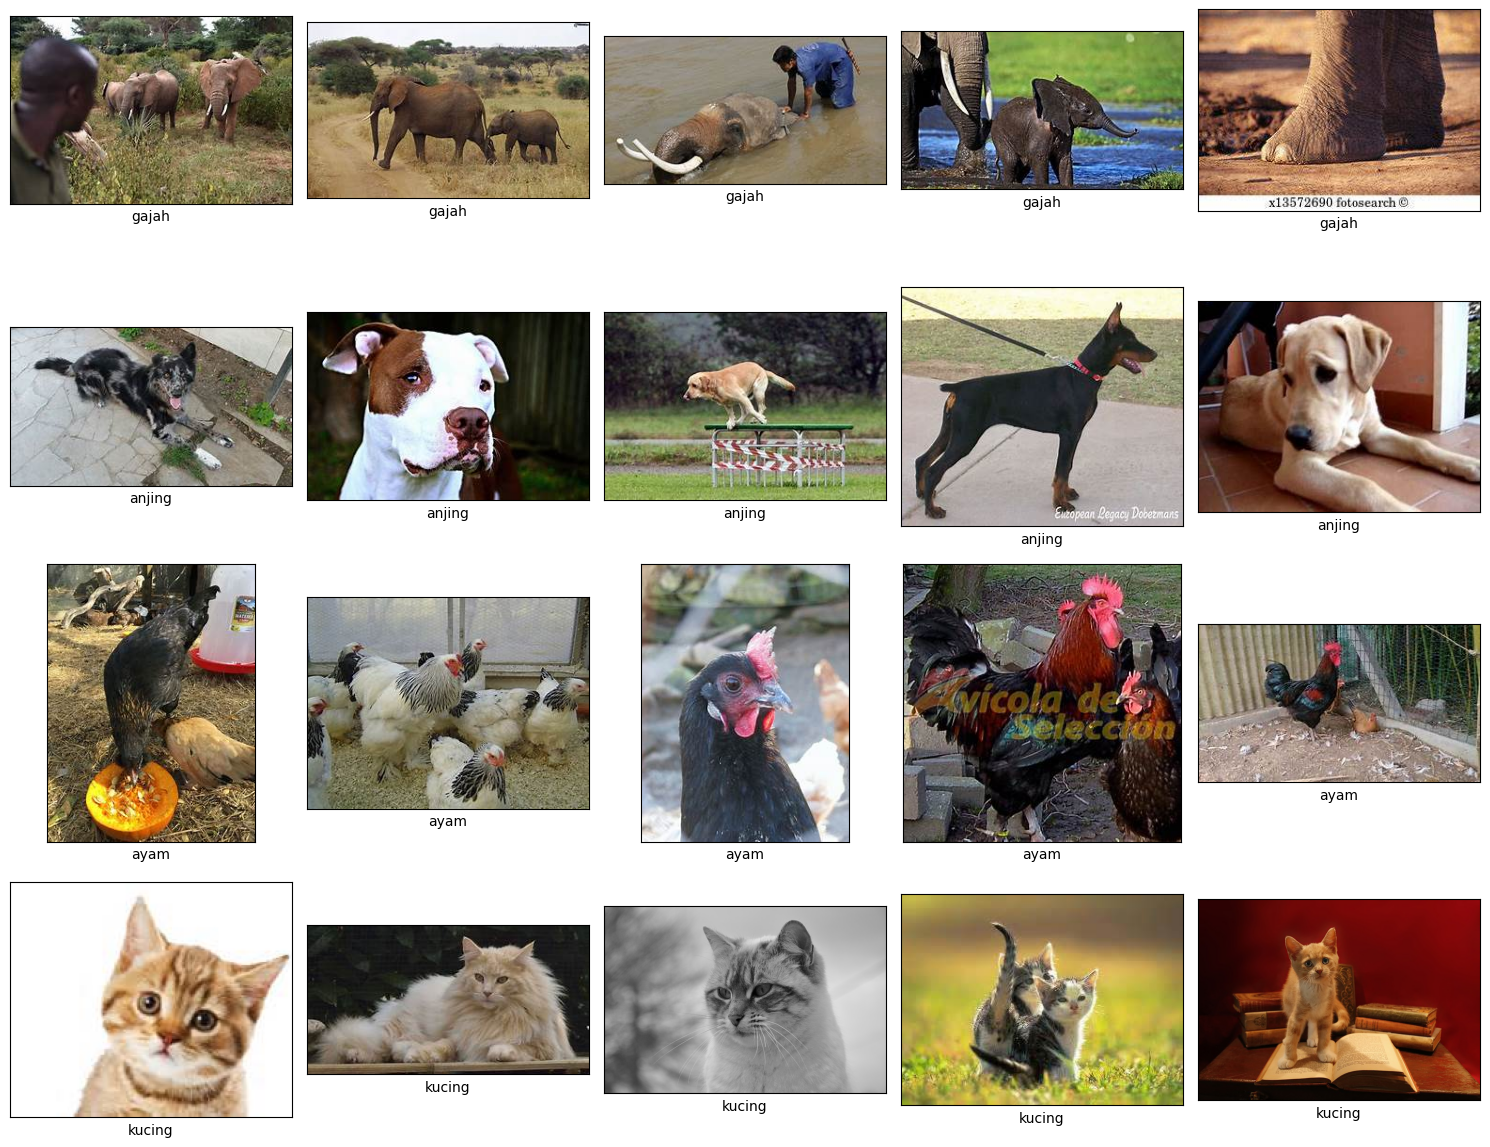

In [2]:
# Direct download link
download_link = "https://drive.usercontent.google.com/download?id=1uyvMFmZje60OKXZtoeRdyRzD4F7rmaeq&export=download&authuser=2&confirm=t&uuid=cbb5b943-d866-4242-a604-492666695b7c&at=APcmpowOmW9hUAGnp2iPp4ls-bG-%3A1744131105965"
extract_path = '/content/hewan'

# Create the directory if it doesn't exist
os.makedirs(extract_path, exist_ok=True) # Create the directory

# Download the zip file
response = requests.get(download_link)
with open(os.path.join(extract_path, "dataset_hewan.zip"), "wb") as f:
    f.write(response.content)

# Extract the zip file
with zipfile.ZipFile(os.path.join(extract_path, "dataset_hewan.zip"), 'r') as zip_ref:
    zip_ref.extractall(extract_path)
print(f"File downloaded and extracted to '{extract_path}'.")

# Path to the dataset
path_sub = os.path.join(extract_path, "dataset hewan fav gweh")
class_names = [i for i in os.listdir(path_sub) if not i.startswith('.')]
print(f"Classes found: {class_names}")

# Tampilkan 5 gambar acak per kelas
fig, axs = plt.subplots(len(class_names), 5, figsize=(15, len(class_names) * 3))
for i, class_name in enumerate(class_names):
    class_dir = os.path.join(path_sub, class_name)
    images = np.random.choice(os.listdir(class_dir), 5, replace=False)
    for j, img_name in enumerate(images):
        img_path = os.path.join(class_dir, img_name)
        img = Image.open(img_path).convert('RGB')
        axs[i, j].imshow(img)
        axs[i, j].set(xlabel=class_name, xticks=[], yticks=[])
fig.tight_layout()
plt.show()

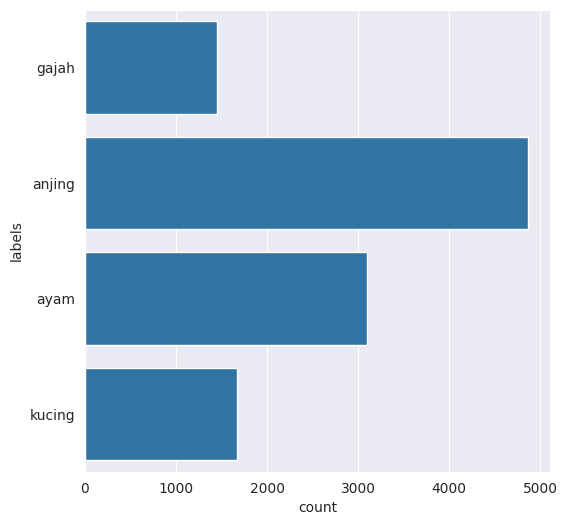

In [3]:
# membuat variabel source path
hewan_path = "/content/hewan/dataset hewan fav gweh"

# Create a list that stores data for each filenames, filepaths, and labels in the data
file_name = []
labels = []
full_path = []

# Get data image filenames, filepaths, labels one by one with looping, and store them as dataframe
for path, subdirs, files in os.walk(hewan_path):
    for name in files:
        full_path.append(os.path.join(path, name))
        labels.append(path.split('/')[-1])
        file_name.append(name)

distribution_train = pd.DataFrame({"path":full_path,'file_name':file_name,"labels":labels})

Label = distribution_train['labels']
plt.figure(figsize = (6,6))
sns.set_style("darkgrid")
plot_data = sns.countplot(Label)

### Data Preprocessing

Data Augmentation

In [4]:
import gc

# Path untuk menyimpan data augmentasi
output_dir = '/content/hewan/augmented'
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

# Definisikan ImageDataGenerator untuk augmentasi
datagen = ImageDataGenerator(
    rotation_range=40,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.3,
    zoom_range=0.3,
    horizontal_flip=True,
    brightness_range=[0.8, 1.2],
    channel_shift_range=10.0,
    fill_mode='nearest'
)

# Batasi jumlah gambar per kelas untuk augmentasi
max_images_per_class = 2000

# Augmentasi untuk setiap kelas
for class_name in class_names:
    class_dir = os.path.join(path_sub, class_name)
    output_class_dir = os.path.join(output_dir, class_name)
    if not os.path.exists(output_class_dir):
        os.makedirs(output_class_dir)

    # Ambil daftar gambar, batasi jumlahnya
    all_images = os.listdir(class_dir)
    if len(all_images) > max_images_per_class:
        all_images = all_images[:max_images_per_class]

    print(f"Memproses {len(all_images)} gambar untuk kelas: {class_name}")

    # Proses gambar satu per satu dalam batch kecil
    batch_size = 32
    for i in range(0, len(all_images), batch_size):
        batch_images = []
        batch_filenames = all_images[i:i + batch_size]

        # Muat batch kecil
        for img_name in batch_filenames:
            img_path = os.path.join(class_dir, img_name)
            try:
                img = Image.open(img_path).convert('RGB')
                img = img.resize((224, 224))
                img_array = np.array(img)
                batch_images.append(img_array)
            except Exception as e:
                print(f"Error loading {img_path}: {e}")
                continue

        if not batch_images:
            continue

        # Konversi ke array 4D
        batch_images = np.array(batch_images)

        # Generate augmentasi untuk batch ini
        j = 0
        for batch in datagen.flow(
            batch_images,
            batch_size=len(batch_images),
            save_to_dir=output_class_dir,
            save_prefix='aug',
            save_format='jpeg'
        ):
            j += 1
            if j >= 3:
                break

    print(f"Augmentasi selesai untuk kelas: {class_name}")
    gc.collect()

Memproses 1446 gambar untuk kelas: gajah
Augmentasi selesai untuk kelas: gajah
Memproses 2000 gambar untuk kelas: anjing
Augmentasi selesai untuk kelas: anjing
Memproses 2000 gambar untuk kelas: ayam
Augmentasi selesai untuk kelas: ayam
Memproses 1668 gambar untuk kelas: kucing
Augmentasi selesai untuk kelas: kucing


#### Split Dataset

In [5]:
# Path ke data asli dan augmentasi
train_dir = '/content/hewan/train'
val_dir = '/content/hewan/val'
test_dir = '/content/hewan/test'

# Buat direktori train, val, dan test
for dir_path in [train_dir, val_dir, test_dir]:
    for class_name in class_names:
        os.makedirs(os.path.join(dir_path, class_name), exist_ok=True)

# Split data asli menjadi train (70%), val (15%), dan test (15%)
for class_name in class_names:
    class_dir = os.path.join(path_sub, class_name)
    images = os.listdir(class_dir)

    # Split pertama: 70% train, 30% (val + test)
    train_imgs, temp_imgs = train_test_split(images, test_size=0.3, random_state=42)
    # Split kedua: dari 30% (temp), bagi menjadi 15% val dan 15% test
    val_imgs, test_imgs = train_test_split(temp_imgs, test_size=0.5, random_state=42)

    # Salin ke direktori train
    for img in train_imgs:
        shutil.copy(os.path.join(class_dir, img), os.path.join(train_dir, class_name, img))
    # Salin ke direktori val
    for img in val_imgs:
        shutil.copy(os.path.join(class_dir, img), os.path.join(val_dir, class_name, img))
    # Salin ke direktori test
    for img in test_imgs:
        shutil.copy(os.path.join(class_dir, img), os.path.join(test_dir, class_name, img))

# Tambahkan data augmentasi ke train
for class_name in class_names:
    aug_dir = os.path.join(output_dir, class_name)
    for img in os.listdir(aug_dir):
        shutil.copy(os.path.join(aug_dir, img), os.path.join(train_dir, class_name, img))

print("Dataset telah dipisah menjadi train, val, dan test.")

Dataset telah dipisah menjadi train, val, dan test.


## Modelling

In [6]:
from tensorflow.keras.callbacks import ReduceLROnPlateau
import tensorflow as tf

# Aktifkan mixed precision training
policy = tf.keras.mixed_precision.Policy('mixed_float16')
tf.keras.mixed_precision.set_global_policy(policy)

# ImageDataGenerator untuk training, validation, dan testing
train_datagen = ImageDataGenerator(rescale=1./255)
val_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

# Generator untuk train, val, dan test
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(224, 224),
    batch_size=128,  # Tingkatkan batch size
    class_mode='categorical'
)

val_generator = val_datagen.flow_from_directory(
    val_dir,
    target_size=(224, 224),
    batch_size=128,
    class_mode='categorical'
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(224, 224),
    batch_size=128,
    class_mode='categorical'
)

model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(224, 224, 3)),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Conv2D(128, (3, 3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Conv2D(256, (3, 3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Conv2D(256, (3, 3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(512, activation='relu'),
    Dropout(0.6),
    Dense(len(class_names), activation='softmax', dtype='float32')
])

# Kompilasi model
model.compile(optimizer=tf.keras.optimizers.RMSprop(learning_rate=0.001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Early stopping
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# Learning rate scheduling
lr_scheduler = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=1)

# Latih model
history = model.fit(
    train_generator,
    epochs=50,  # Kurangi epoch
    validation_data=val_generator,
    callbacks=[early_stopping, lr_scheduler]
)

# Simpan model setelah training
model.save('/content/hewan_model.keras')

Found 28895 images belonging to 4 classes.
Found 1661 images belonging to 4 classes.
Found 1663 images belonging to 4 classes.


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/50
226/226 ━━━━━━━━━━━━━━━━━━━━ 277s 743ms/step - accuracy: 0.4232 - loss: 2.7664 - val_accuracy: 0.1993 - val_loss: 3.1444 - learning_rate: 0.0010
Epoch 2/50
226/226 ━━━━━━━━━━━━━━━━━━━━ 69s 306ms/step - accuracy: 0.6540 - loss: 0.8520 - val_accuracy: 0.6731 - val_loss: 0.8415 - learning_rate: 0.0010
Epoch 3/50
226/226 ━━━━━━━━━━━━━━━━━━━━ 58s 258ms/step - accuracy: 0.7368 - loss: 0.6615 - val_accuracy: 0.7357 - val_loss: 0.7076 - learning_rate: 0.0010
Epoch 4/50
226/226 ━━━━━━━━━━━━━━━━━━━━ 69s 306ms/step - accuracy: 0.7977 - loss: 0.5400 - val_accuracy: 0.7977 - val_loss: 0.6436 - learning_rate: 0.0010
Epoch 5/50
226/226 ━━━━━━━━━━━━━━━━━━━━ 71s 315ms/step - accuracy: 0.8397 - loss: 0.4406 - val_accuracy: 0.8567 - val_loss: 0.4564 - learning_rate: 0.0010
Epoch 6/50
226/226 ━━━━━━━━━━━━━━━━━━━━ 80s 307ms/step - accuracy: 0.8637 - loss: 0.3678 - val_accuracy: 0.8447 - val_loss: 0.6296 - learning_rate: 0.0010
Epoch 7/50
226/226 ━━━━━━━━━━━━━━━━━━━━ 59s 259ms/step - accuracy: 0.

## Evaluasi dan Visualisasi

226/226 ━━━━━━━━━━━━━━━━━━━━ 66s 293ms/step - accuracy: 0.9665 - loss: 0.0992
13/13 ━━━━━━━━━━━━━━━━━━━━ 4s 340ms/step - accuracy: 0.9143 - loss: 0.2886
13/13 ━━━━━━━━━━━━━━━━━━━━ 11s 909ms/step - accuracy: 0.9004 - loss: 0.4258
Training Loss: 0.1002, Training Accuracy: 0.9662 (96.62%)
Validation Loss: 0.2701, Validation Accuracy: 0.9199 (91.99%)
Test Loss: 0.3592, Test Accuracy: 0.9056 (90.56%)


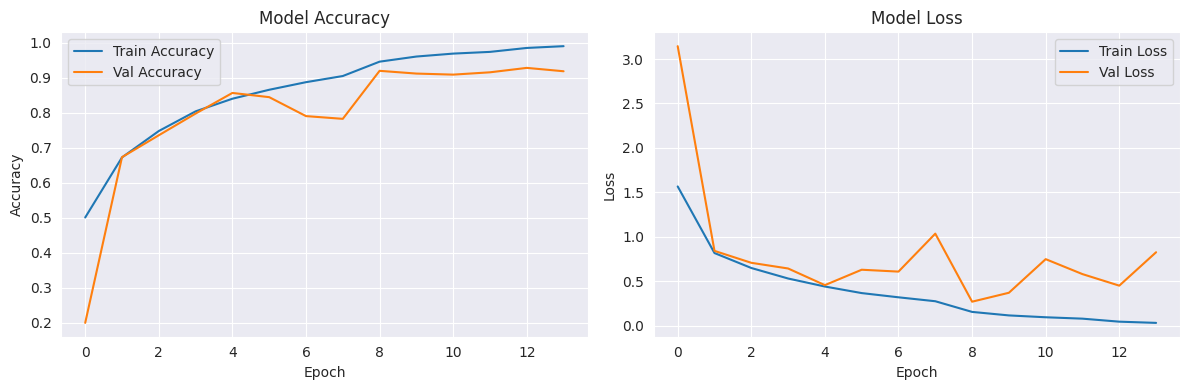

In [7]:
# Evaluasi model pada train, val, dan test set
train_loss, train_acc = model.evaluate(train_generator)
val_loss, val_acc = model.evaluate(val_generator)
test_loss, test_acc = model.evaluate(test_generator)

print(f"Training Loss: {train_loss:.4f}, Training Accuracy: {train_acc:.4f} ({train_acc*100:.2f}%)")
print(f"Validation Loss: {val_loss:.4f}, Validation Accuracy: {val_acc:.4f} ({val_acc*100:.2f}%)")
print(f"Test Loss: {test_loss:.4f}, Test Accuracy: {test_acc:.4f} ({test_acc*100:.2f}%)")

# Visualisasi akurasi dan loss
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

## Konversi Model

In [3]:
import tensorflow as tf
!pip install tensorflowjs

# Load trained model
model = tf.keras.models.load_model('/content/hewan_model.keras')

# Simpan model dalam format SavedModel
tf.saved_model.save(model, '/content/hewan_model')

# Konversi ke TFLite
converter = tf.lite.TFLiteConverter.from_saved_model('/content/hewan_model')
converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.target_spec.supported_ops = [
  tf.lite.OpsSet.TFLITE_BUILTINS,
  tf.lite.OpsSet.SELECT_TF_OPS
]
tflite_model = converter.convert()

# Simpan model TFLite
with open('/content/hewan_model.tflite', 'wb') as f:
    f.write(tflite_model)

# Konversi ke TFJS
!tensorflowjs_converter --input_format=tf_saved_model --output_format=tfjs_graph_model /content/hewan_model /content/hewan_model_tfjs

print("Model telah dikonversi ke format SavedModel, TFLite, dan TFJS.")
print("SavedModel disimpan di: /content/hewan_model")
print("TFLite disimpan sebagai: /content/hewan_model.tflite")
print("TFJS disimpan di: /content/hewan_model_tfjs")

/usr/local/lib/python3.11/dist-packages/keras/src/saving/saving_lib.py:757: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 26 variables whereas the saved optimizer has 30 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


2025-04-09 11:59:45.463845: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1744199985.485134    9718 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1744199985.491791    9718 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1744199985.507448    9718 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1744199985.507477    9718 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1744199985.507481    9718 computation_placer.cc:177] computation placer alr

## Inference (Optional)

In [5]:
import tensorflow as tf
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

# Load trained model
model = tf.keras.models.load_model('/content/hewan_model.keras')

def preprocess_image(image_path):
    img = Image.open(image_path).convert('RGB')
    img = img.resize((224, 224))
    img_array = np.array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)
    return img_array

# path gambar untuk diklasifikasi
image_path = '/content/gambar_untuk_test_model.jpg'

preprocessed_image = preprocess_image(image_path)
predictions = model.predict(preprocessed_image)
predicted_class = np.argmax(predictions[0])

print(f"Predicted class: {predicted_class}")

class_names = ['gajah', 'anjing', 'ayam', 'kucing']

predicted_class_name = class_names[predicted_class]
print(f"Predicted class name: {predicted_class_name}")
print(f"Probability: {predictions[0][predicted_class]}")

img = Image.open(image_path).convert('RGB')
plt.imshow(img)
plt.title(f'Predicted: {predicted_class_name} (Probability: {predictions[0][predicted_class]:.2f})')
plt.axis('off')
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 790ms/step
Predicted class: 3
Predicted class name: kucing
Probability: 1.0
